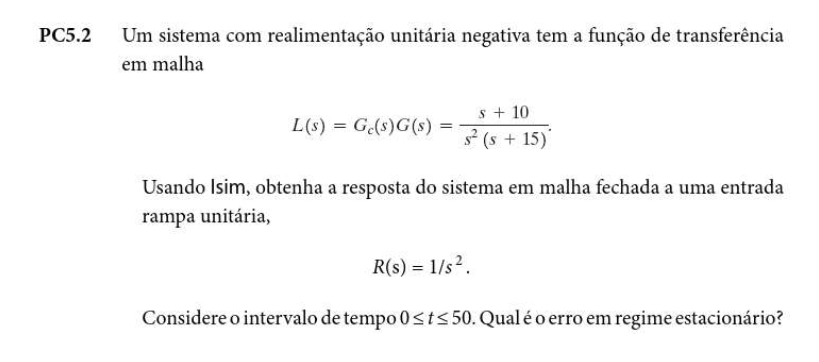

PROBLEMA PC5.2 - RESPOSTA A RAMPA UNITÁRIA COM REALIMENTAÇÃO

(a) FUNÇÃO DE TRANSFERÊNCIA EM MALHA ABERTA:
---------------------------------------------------------------------------
L(s) = G_c(s)G(s) =
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     s + 10
  ------------
  s^3 + 15 s^2

(b) FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:
---------------------------------------------------------------------------
T(s) = L(s) / (1 + L(s)) = Y(s) / R(s) =
<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         s + 10
  ---------------------
  s^3 + 15 s^2 + s + 10

Numerador: [ 1 10]
Denominador: [array([ 1, 15,  1, 10])]

(c) ANÁLISE DA RESPOSTA À RAMPA UNITÁRIA:
---------------------------------------------------------------------------

Intervalo de tempo: 0 ≤ t ≤ 50 s

No tempo final (t = 50.0 s):
  Entrada r(t) = 50.0000
  Saída y(t) = 50.0074
  Erro e(t) = r(t) - y(t) = -0.007395

(d) ERRO DE REGIME ESTACIONÁRIO TEÓRICO:
---------------

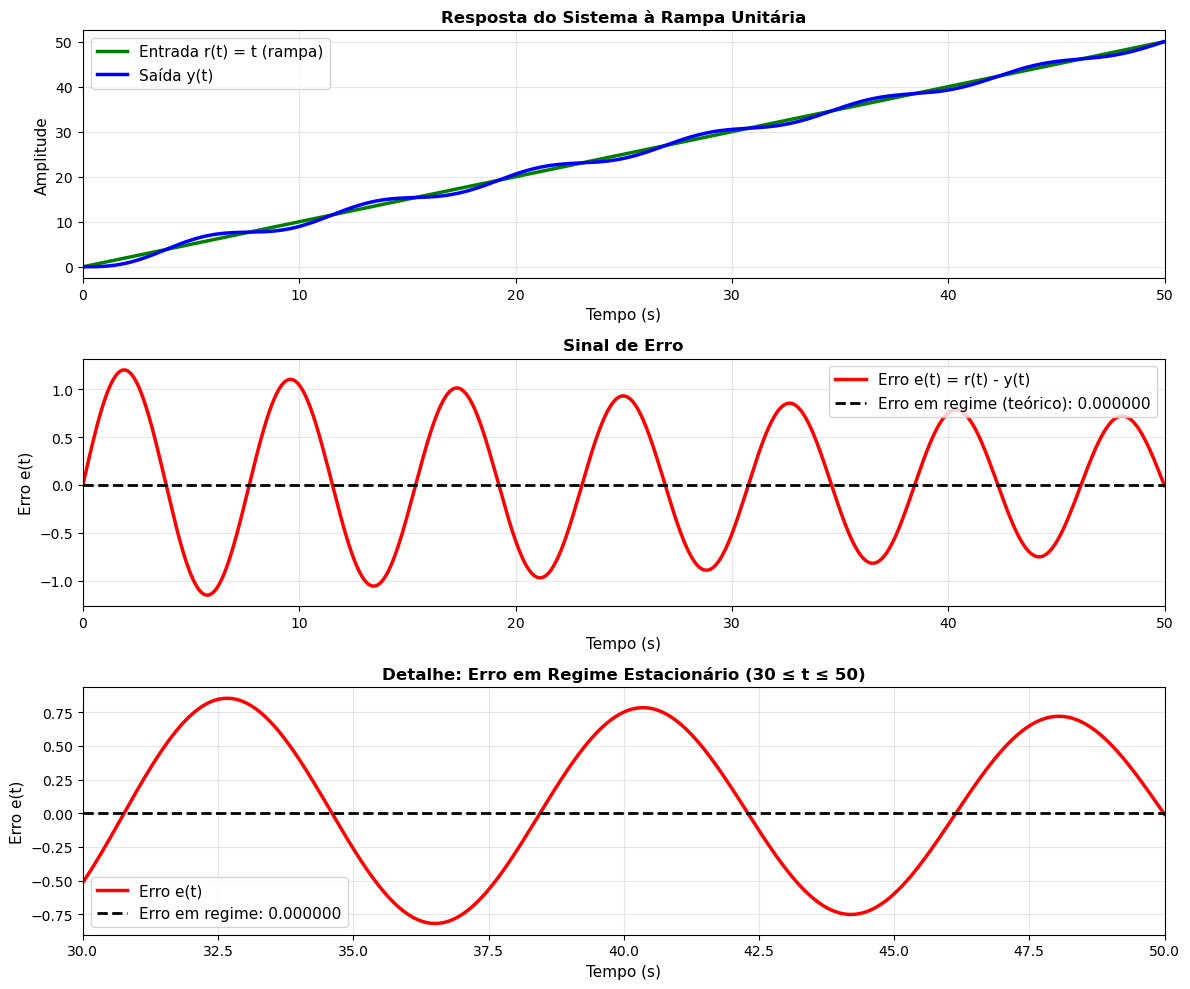


Gráficos salvos como 'rampa_response.png'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

print("=" * 75)
print("PROBLEMA PC5.2 - RESPOSTA A RAMPA UNITÁRIA COM REALIMENTAÇÃO")
print("=" * 75)

# Define the open-loop transfer function
# L(s) = G_c(s)G(s) = (s + 10) / (s²(s + 15))
num_L = [1, 10]           # numerador: s + 10
den_L = [1, 15, 0, 0]     # denominador: s(s+15)s = s²(s+15)

# Create the open-loop transfer function
L = ct.TransferFunction(num_L, den_L)

print("\n(a) FUNÇÃO DE TRANSFERÊNCIA EM MALHA ABERTA:")
print("-" * 75)
print("L(s) = G_c(s)G(s) =")
print(L)

# Calculate the closed-loop transfer function
# T(s) = L(s) / (1 + L(s)) = Y(s) / R(s)
T = ct.feedback(L)

print("\n(b) FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:")
print("-" * 75)
print("T(s) = L(s) / (1 + L(s)) = Y(s) / R(s) =")
print(T)

# Extract numerator and denominator for analysis
num_T, den_T = ct.tfdata(T)
num_T = num_T[0][0]
den_T = den_T[0]

print("\nNumerador:", num_T)
print("Denominador:", den_T)

# Define time vector: 0 ≤ t ≤ 50
t = np.linspace(0, 50, 2000)

# Unit ramp input: r(t) = t
r = t

# Calculate the system response to the ramp input using lsim
t_out, y = ct.forced_response(T, T=t, U=r)

# Calculate the error signal: e(t) = r(t) - y(t)
e = r - y

# Steady-state error (at the end of the simulation)
e_ss = e[-1]
y_ss = y[-1]
r_ss = r[-1]

print("\n(c) ANÁLISE DA RESPOSTA À RAMPA UNITÁRIA:")
print("-" * 75)
print(f"\nIntervalo de tempo: 0 ≤ t ≤ 50 s")
print(f"\nNo tempo final (t = {t[-1]} s):")
print(f"  Entrada r(t) = {r_ss:.4f}")
print(f"  Saída y(t) = {y_ss:.4f}")
print(f"  Erro e(t) = r(t) - y(t) = {e_ss:.6f}")

# Theoretical steady-state error for ramp input
# For a system with open-loop L(s), the velocity error constant K_v is:
# K_v = lim(s→0) s*L(s)
# e_ss = 1/K_v for a unit ramp

# Calculate K_v using limit
# L(s) = (s + 10) / (s²(s + 15))
# s*L(s) = (s + 10) / (s(s + 15))
# As s→0: K_v = 10/15 = 2/3

# For unit ramp: e_ss = 1/K_v
num_sL = [1, 10]          # s + 10
den_sL = [1, 15, 0]       # s(s + 15)

sL = ct.TransferFunction(num_sL, den_sL)
K_v = ct.dcgain(sL)

print(f"\n(d) ERRO DE REGIME ESTACIONÁRIO TEÓRICO:")
print("-" * 75)
print(f"\nConstante de erro de velocidade (Velocity Error Constant):")
print(f"K_v = lim(s→0) s*L(s) = {K_v:.6f}")

e_ss_theoretical = 1 / K_v if K_v != 0 else float('inf')
print(f"\nErro de regime estacionário para rampa unitária:")
print(f"e_ss = 1/K_v = {e_ss_theoretical:.6f}")

print(f"\nErro simulado ao final de 50 segundos: {e_ss:.6f}")
print(f"Diferença: {abs(e_ss - e_ss_theoretical):.6f}")

# Create plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Input and output
axes[0].plot(t_out, r, 'g-', linewidth=2.5, label='Entrada r(t) = t (rampa)')
axes[0].plot(t_out, y, 'b-', linewidth=2.5, label='Saída y(t)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Tempo (s)', fontsize=11)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Resposta do Sistema à Rampa Unitária', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 50)

# Plot 2: Error signal
axes[1].plot(t_out, e, 'r-', linewidth=2.5, label='Erro e(t) = r(t) - y(t)')
axes[1].axhline(y=e_ss_theoretical, color='k', linestyle='--', linewidth=2, 
                label=f'Erro em regime (teórico): {e_ss_theoretical:.6f}')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Tempo (s)', fontsize=11)
axes[1].set_ylabel('Erro e(t)', fontsize=11)
axes[1].set_title('Sinal de Erro', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xlim(0, 50)

# Plot 3: Zoomed view of steady-state error region
start_idx = np.where(t_out >= 30)[0][0]
axes[2].plot(t_out[start_idx:], e[start_idx:], 'r-', linewidth=2.5, label='Erro e(t)')
axes[2].axhline(y=e_ss_theoretical, color='k', linestyle='--', linewidth=2,
                label=f'Erro em regime: {e_ss_theoretical:.6f}')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Tempo (s)', fontsize=11)
axes[2].set_ylabel('Erro e(t)', fontsize=11)
axes[2].set_title('Detalhe: Erro em Regime Estacionário (30 ≤ t ≤ 50)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].set_xlim(30, 50)

plt.tight_layout()
plt.savefig('rampa_response.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 75)
print("Gráficos salvos como 'rampa_response.png'")
print("=" * 75)